# Stage 1 - Forecast the customer portfolio

**Input:** customer table (Data Description) and `slp_profiles.csv`

**Output:** quarter-hourly forecast load for each customer group (HB/GB/LB) and the total portfolio
(`data/forecast_load.csv`)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

DATA = "../data"
C = ["#4C72B0", "#DD8452", "#55A868"]   # HB, GB, LB

slp = pd.read_csv(f"{DATA}/slp_profiles.csv")

# local time from timestamp_utc (timestamp_local carries changing UTC offsets)
t_local = pd.to_datetime(slp["timestamp_utc"], utc=True).dt.tz_convert("Europe/Berlin")
slp["hour"]       = t_local.dt.hour
slp["weekday"]    = t_local.dt.weekday
slp["is_weekend"] = slp["weekday"] >= 5
slp["month"]      = t_local.dt.month

print("shape:", slp.shape, " -> 366 days x 96 quarter-hours =", 366 * 96)
print("missing values:", int(slp[["hb_normalized_kwh", "gb_normalized_kwh", "lb_normalized_kwh"]].isna().sum().sum()))
slp.head()

shape: (35136, 9)  -> 366 days x 96 quarter-hours = 35136
missing values: 0


,timestamp_utc,timestamp_local,hb_normalized_kwh,gb_normalized_kwh,lb_normalized_kwh,hour,weekday,is_weekend,month
0,2023-12-31T23:00:00Z,2024-01-01T00:00:00+01:00,27.11,15.71,17.03,0,0,False,1
1,2023-12-31T23:15:00Z,2024-01-01T00:15:00+01:00,25.13,15.16,16.45,0,0,False,1
2,2023-12-31T23:30:00Z,2024-01-01T00:30:00+01:00,23.24,14.64,16.03,0,0,False,1
3,2023-12-31T23:45:00Z,2024-01-01T00:45:00+01:00,21.41,14.16,15.71,0,0,False,1
4,2024-01-01T00:00:00Z,2024-01-01T01:00:00+01:00,19.64,13.74,15.48,1,0,False,1


## 1. Annual portfolio energy per profile  $E_p = n_p \cdot e_p$

Number of customers $n_p$ and annual consumption per
customer $e_p$.

In [ ]:
customers = pd.DataFrame(
    {"n": [10_000, 200, 20], "e_mwh_per_customer": [3.5, 30.0, 100.0]},
    index=["HB", "GB", "LB"],
)
customers["E_MWh"]     = customers["n"] * customers["e_mwh_per_customer"]
customers["share_pct"] = 100 * customers["E_MWh"] / customers["E_MWh"].sum()

print(f"Annual portfolio energy: {customers['E_MWh'].sum():,.2f} MWh")
customers

Annual portfolio energy: 43,000.00 MWh


,n,e_mwh_per_customer,E_MWh,share_pct
HB,10000,3.50,"35,000.00",81.40
GB,200,30.00,"6,000.00",13.95
LB,20,100.00,"2,000.00",4.65


## 2. Scale the SLP to real energy  $L_{p,t} = E_p \cdot \dfrac{s_{p,t}}{\sum_\tau s_{p,\tau}}$

Each $s_{p,t}$ column (\*_normalized_kwh) only gives us the shape of consumption over time, it is a normalized value and sums to 1,000,000 kWh a year. To convert this generic shape into our portfolio's actual consumption ($L_{p,t}$), we apply simple scaling:

1. $\dfrac{s_{p,t}}{\sum_\tau s_{p,\tau}}$: Finds the percentage share of a specific 15-minute interval relative to the entire year.
2. **Multiplying by $E_p$**: Scales that percentage to match our customer group's real annual volume ($E_p$).




In [3]:
col = {"HB": "hb_normalized_kwh", "GB": "gb_normalized_kwh", "LB": "lb_normalized_kwh"}

annual_norm_kwh = {g: slp[c].sum() for g, c in col.items()}
print("annual sum of normalized profile [kWh]:", {g: round(v, 2) for g, v in annual_norm_kwh.items()})

factor = {g: customers.loc[g, "E_MWh"] * 1_000 / annual_norm_kwh[g] for g in col}
print("scaling factor:", {g: round(v, 2) for g, v in factor.items()})

load = pd.DataFrame(index=slp.index)
for g, c in col.items():
    load[g] = customers.loc[g, "E_MWh"] * slp[c] / slp[c].sum()   # MWh per quarter-hour

# L_t = sum_p L_p,t
load["total"] = load[["HB", "GB", "LB"]].sum(axis=1)

for k in ["hour", "weekday", "is_weekend", "month"]:
    load[k] = slp[k]

load[["HB", "GB", "LB", "total"]].describe()

annual sum of normalized profile [kWh]: {'HB': np.float64(1000000.0), 'GB': np.float64(1000000.0), 'LB': np.float64(1000000.0)}
scaling factor: {'HB': np.float64(35.0), 'GB': np.float64(6.0), 'LB': np.float64(2.0)}


,HB,GB,LB,total
count,"35,136.00","35,136.00","35,136.00","35,136.00"
mean,1.00,0.17,0.06,1.22
std,0.43,0.09,0.02,0.49
min,0.32,0.06,0.02,0.42
25%,0.60,0.10,0.03,0.74
50%,1.04,0.13,0.05,1.31
75%,1.27,0.26,0.07,1.57
max,2.34,0.36,0.12,2.60


## 3. Reconciliation

We sum all 35,136 quarter-hourly predictions ($L_t$) across the entire year. The result must exactly equal our total portfolio target of $43,000.00 \text{ MWh}$. ($\text{MW} = \text{MWh} / 0.25\,\text{h} = \text{MWh} \times 4$).


In [ ]:
check = pd.DataFrame({
    "E_target_MWh": customers["E_MWh"],
    "sum_L_MWh":    [load["HB"].sum(), load["GB"].sum(), load["LB"].sum()],
})
check["diff"] = check["sum_L_MWh"] - check["E_target_MWh"]
check.loc["Total"] = check.sum()

assert np.allclose(check.loc[["HB", "GB", "LB"], "diff"], 0, atol=1e-6)
print("Reconciliation ok - annual energy matches the customer table exactly.")
print(f"Average portfolio power: {load['total'].sum() / (366 * 24):,.2f} MW")
print(f"Total load range: {load['total'].min() * 4:,.2f} - {load['total'].max() * 4:,.2f} MW")
check

Reconciliation ok - annual energy matches the customer table exactly.
Average portfolio power: 4.90 MW
Total load range: 1.68 - 10.40 MW


,E_target_MWh,sum_L_MWh,diff
HB,"35,000.00","35,000.00",0.00
GB,"6,000.00","6,000.00",-0.00
LB,"2,000.00","2,000.00",0.00
Total,"43,000.00","43,000.00",-0.00


## 4. How the customer mix drives the daily and seasonal shape

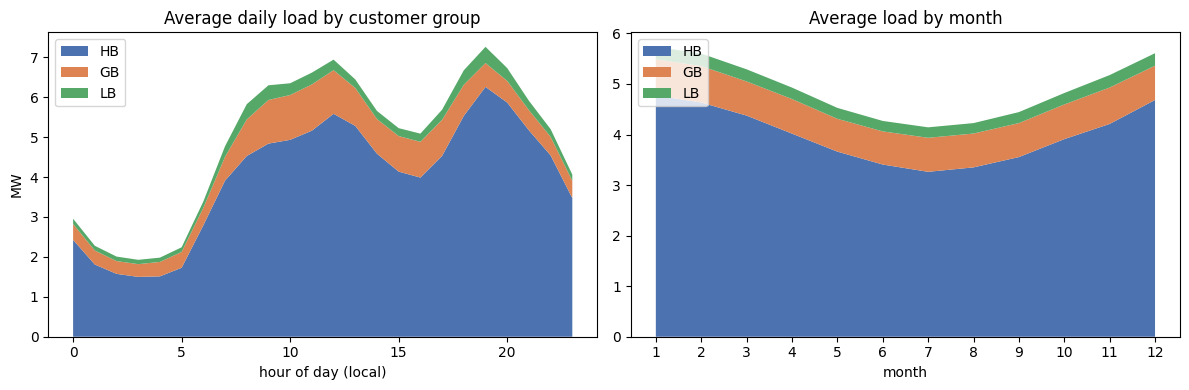

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

hourly = load.groupby("hour")[["HB", "GB", "LB", "total"]].mean() * 4   # MWh/qh -> MW
axes[0].stackplot(hourly.index, hourly["HB"], hourly["GB"], hourly["LB"], labels=["HB", "GB", "LB"], colors=C)
axes[0].set_title("Average daily load by customer group")
axes[0].set_xlabel("hour of day (local)"); axes[0].set_ylabel("MW")
axes[0].legend(loc="upper left")

monthly = load.groupby("month")[["HB", "GB", "LB"]].mean() * 4
axes[1].stackplot(monthly.index, monthly["HB"], monthly["GB"], monthly["LB"], labels=["HB", "GB", "LB"], colors=C)
axes[1].set_title("Average load by month")
axes[1].set_xlabel("month"); axes[1].set_xticks(range(1, 13))
axes[1].legend(loc="upper left")

plt.tight_layout(); plt.show()

**Comment.** HB (household) carries 81.40% of the portfolio energy, so the total load shape is
almost entirely residential: an evening peak around 19-20h, a night dip, and strong seasonality
(winter >> summer). GB (general business, 13.95%) adds a classic weekday/business-hours block, but
it isn't big enough to flip the total shape. LB (agricultural businesses, 4.65%) is nearly flat.

**What this means for Base/Peak futures:** the portfolio never drops below ~1.7 MW, so a sizeable
**Base** component makes sense. But HB's evening peak keeps going past 20:00 and doesn't drop on
weekends, so the standard **Peak** window (Mon-Fri 08-20) misses part of it — only the GB share
fits cleanly inside the Peak window. The strong seasonality is also a reason to stagger the hedge
**quarter by quarter** rather than flat across the year (we come back to this in Stage 2/3).

## 5. Save the forecast 

In [6]:
out = load[["HB", "GB", "LB", "total"]].copy()
out.insert(0, "timestamp_utc", slp["timestamp_utc"].values)
out.to_csv(f"{DATA}/forecast_load.csv", index=False)
print("saved:", f"{DATA}/forecast_load.csv", out.shape)
out.head()

saved: ../data/forecast_load.csv (35136, 5)


,timestamp_utc,HB,GB,LB,total
0,2023-12-31T23:00:00Z,0.95,0.09,0.03,1.08
1,2023-12-31T23:15:00Z,0.88,0.09,0.03,1.00
2,2023-12-31T23:30:00Z,0.81,0.09,0.03,0.93
3,2023-12-31T23:45:00Z,0.75,0.08,0.03,0.87
4,2024-01-01T00:00:00Z,0.69,0.08,0.03,0.80
